In [1]:
!pip install sentence-transformers

In [2]:
import re
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util

In [3]:
job_description = """
We are hiring a VLSI Engineer with experience in Verilog,
FPGA, Digital Design, ASIC flow, Python and Machine Learning basics.
Minimum 2 years experience required.
"""

In [4]:
resumes = [
"""
John Doe
3 years experience in VLSI design.
Skilled in Verilog, FPGA, ASIC flow and Python.
""",

"""
Rahul Sharma
Software engineer with Python and Machine Learning expertise.
2 years experience.
""",

"""
Priya Singh
Electronics engineer with FPGA and Digital Design.
1 year experience.
""",

"""
Arjun Mehta
4 years experience in ASIC design and Verilog.
Strong background in Digital Systems.
""",

"""
Kiran Patel
Mechanical engineer with CAD and manufacturing skills.
5 years experience.
"""
]

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text

def extract_years(text):
    years = re.findall(r'(\d+)\s+year', text)
    if years:
        return int(years[0])
    return 0

In [6]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
skill_weights = {
    "verilog": 0.2,
    "fpga": 0.2,
    "digital design": 0.2,
    "asic": 0.15,
    "python": 0.15,
    "machine learning": 0.1
}

def skill_score(text):
    score = 0
    for skill, weight in skill_weights.items():
        if skill in text:
            score += weight
    return score

def experience_score(years):
    return min(years * 0.1, 1)

def final_score(semantic, skill, exp):
    return (0.5 * semantic) + (0.3 * skill) + (0.2 * exp)

In [8]:
jd_clean = clean_text(job_description)
jd_embedding = model.encode(jd_clean, convert_to_tensor=True)

results = []

for resume in resumes:
    cleaned = clean_text(resume)
    resume_embedding = model.encode(cleaned, convert_to_tensor=True)

    semantic = float(util.cos_sim(jd_embedding, resume_embedding))
    skill = skill_score(cleaned)
    years = extract_years(cleaned)
    exp = experience_score(years)

    total = final_score(semantic, skill, exp)

    name = resume.strip().split("\n")[0]

    results.append({
        "Name": name,
        "Semantic Score": semantic,
        "Skill Score": skill,
        "Experience Score": exp,
        "Final AI Fit Score": total
    })

df = pd.DataFrame(results)
df = df.sort_values(by="Final AI Fit Score", ascending=False)

df

,Name,Semantic Score,Skill Score,Experience Score,Final AI Fit Score
0,John Doe,0.859594,0.70,0.3,0.699797
2,Priya Singh,0.636923,0.40,0.1,0.458461
3,Arjun Mehta,0.534216,0.35,0.4,0.452108
1,Rahul Sharma,0.635388,0.25,0.2,0.432694
4,Kiran Patel,0.401513,0.00,0.5,0.300756


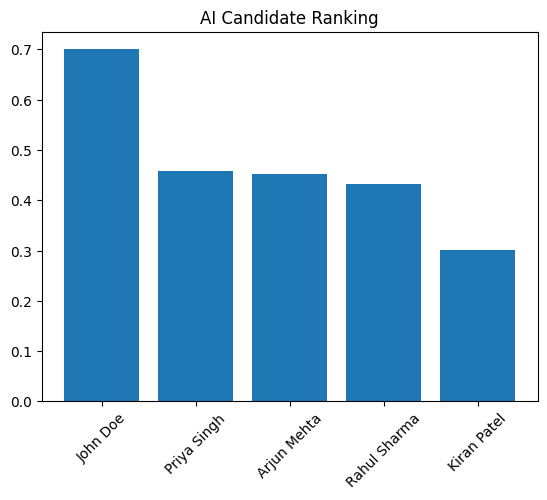

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df["Name"], df["Final AI Fit Score"])
plt.xticks(rotation=45)
plt.title("AI Candidate Ranking")
plt.show()